<a href="https://colab.research.google.com/github/aaronseymour7/sandbox/blob/main/1DHeis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install netket

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.5/833.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
import netket as nk
import numpy as np

def lanczos_gs(n_sites, pbc=True):

    graph = nk.graph.Hypercube(length=n_sites, n_dim=1, pbc=pbc)
    hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=graph.n_nodes)
    hamiltonian = nk.operator.Heisenberg(hilbert=hi, graph=graph, J=1.0)

    result = nk.exact.lanczos_ed(hamiltonian, k=1, compute_eigenvectors=False)

    return result[0]


N = 12
exact_energy = lanczos_gs(N)

print(f"Lattice Size: {N}")
print(f"Exact Ground State Energy: {exact_energy:.6f}")
print(f"Energy per site: {exact_energy/N:.6f}")

Lattice Size: 12
Exact Ground State Energy: -21.549564
Energy per site: -1.795797


In [ ]:
import netket as nk
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def get_comparison_data(n_sites_list):
    results = []

    for n in n_sites_list:
        print(f"--- Analyzing N = {n} ---")

        # Lattice and Hamiltonian
        #graph = nk.graph.Hypercube(length=n, n_dim=1, pbc=True)
        graph=nk.graph.Chain(n)
        hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=graph.n_nodes)
        hamiltonian = nk.operator.Heisenberg(hilbert=hi, graph=graph)

        # Exact Ground State (Lanczos)
        e_exact = None
        if n <= 22:
            ed_result = nk.exact.lanczos_ed(hamiltonian, k=1)
            e_exact = float(ed_result[0])

        # 3. Neural Network (RBM)
        model = nk.models.RBM(alpha=2, param_dtype=float)
        sampler = nk.sampler.MetropolisExchange(hi, graph=graph)

        vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

# Neel state

        n_chains = vstate.sampler.n_chains
        neel = np.ones(n)
        neel[1::2] = -1

        neel_samples = np.tile(neel, (n_chains, 1)).astype(np.int8)


        vstate.sampler_state = vstate.sampler_state.replace(σ=jnp.array(neel_samples))

        # Optimizer: Stochastic Reconfiguration (SR)
        optimizer = nk.optimizer.Sgd(learning_rate=0.02)
        sr = nk.optimizer.SR(diag_shift=0.1)
        vmc = nk.driver.VMC(hamiltonian, optimizer, variational_state=vstate, preconditioner=sr)

        #log = nk.logging.RuntimeLog()

        # Optimization
        vmc.run(n_iter=400,out=log)
        history = log.data
        print(history['Energy'].Mean)


        stats = vstate.expect(hamiltonian)
        e_vmc = float(stats.mean.real)
        err_vmc = float(stats.error_of_mean)

        results.append({
            "N": n,
            "Exact": e_exact,
            "VMC": e_vmc,
            "VMC_err": err_vmc,
            "Error": abs(e_exact - e_vmc) if e_exact else None
        })

    return results;
#n_sizes = [10,16,20,22,24,26]
n_sizes = [10,16,24]
data = get_comparison_data(n_sizes)

# 4. Print

for d in data:
    status = f"Diff: {d['Error']:.6f}" if d['Error'] is not None else "Exact not computed"
    print(f"N={d['N']} | VMC: {d['VMC']:.5f} | {status}")

--- Analyzing N = 10 ---


  0%|          | 0/400 [00:00<?, ?it/s]

[-12.19894093 -12.18002808 -13.07373814 -14.04367122 -14.98040215
 -15.98664582 -16.68345076 -16.86972816 -17.12772609 -17.2297629
 -17.32388979 -17.39417103 -17.51864981 -17.42050943 -17.55306041
 -17.32842087 -17.66052042 -17.53030577 -17.56372865 -17.6627838
 -17.58412576 -17.65427573 -17.75522779 -17.72644473 -17.84810766
 -17.89593381 -17.90445828 -17.9679711  -17.92861741 -18.01221682
 -17.96981808 -17.98631122 -18.03178568 -17.97891343 -18.02416493
 -18.03308977 -18.0471459  -18.01025374 -18.00592505 -18.0193117
 -18.03971367 -18.01196171 -18.00863453 -18.06763452 -18.06311285
 -18.05195913 -18.02001229 -18.06205549 -18.0550773  -18.07902964
 -18.04110741 -18.05233557 -18.05646773 -18.0392431  -18.0416359
 -18.02008022 -18.03147034 -18.04839732 -18.05110329 -18.05794232
 -18.0560778  -18.05419528 -18.0497596  -18.07154669 -18.04929567
 -18.05212318 -18.04777724 -18.06430499 -18.07134905 -18.05924253
 -18.04902901 -18.06460792 -18.0514169  -18.06833902 -18.05895928
 -18.05706213 

  0%|          | 0/400 [00:00<?, ?it/s]

[-18.2958901  -18.38432358 -19.79435894 -21.37609538 -22.90584237
 -24.05175386 -25.28610186 -25.72265375 -25.64808274 -25.9378502
 -26.39283237 -26.51725894 -26.77442605 -26.98125626 -27.29127856
 -26.93567417 -27.30557932 -27.38915006 -27.4415324  -27.29943299
 -26.96848786 -27.2480032  -27.22398826 -27.29425171 -27.34922666
 -27.54278566 -27.65960356 -27.39955633 -27.27794518 -27.45568086
 -27.34783416 -27.79429151 -27.82917637 -27.791389   -27.94219595
 -27.90254211 -27.83464222 -27.94483141 -27.95228625 -27.99111523
 -27.92926746 -27.91290849 -28.02962627 -28.11379528 -28.06859543
 -28.08424    -28.12500817 -27.99359643 -28.0855465  -27.98613401
 -28.13279268 -28.05135414 -28.16519647 -27.98005692 -28.09116003
 -28.04926855 -28.1735216  -28.141536   -28.10427365 -28.15444579
 -28.10522094 -28.08172753 -28.19443905 -28.26447362 -28.21216755
 -28.23689346 -28.14838396 -28.16956799 -28.17338793 -28.34356095
 -28.21904301 -28.20420799 -28.36192425 -28.19489548 -28.34765688
 -28.356948

/tmp/ipython-input-3617741692.py:44: InsufficientSamplesForSRWarning: 
The number of samples (1008) is less than or equal to the number of parameters (1224).

In this regime, the standard QGT-based SR formulation is inefficient and potentially unstable.
You should switch to the kernel/minSR formulation by using:

    nk.driver.VMC_SR(hamiltonian, optimizer, diag_shift=0.01, variational_state=your_state)

instead of:

    nk.driver.VMC(hamiltonian, optimizer, preconditioner=nk.optimizer.SR())

VMC_SR automatically chooses the optimal implementation and is always recommended when using SR.
This provides the same mathematical result but with much better performance and numerical stability.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generated/errors/netket.errors.InsufficientSamplesForSRWarning.html
or the list of all common errors and warnings at
	 https://netket.readthe

  0%|          | 0/400 [00:00<?, ?it/s]

[-25.9807738  -27.2973403  -28.54266005 -30.82221892 -33.59564894
 -36.09498398 -35.64073348 -37.25432672 -38.38148174 -38.33722716
 -38.65742663 -39.3742659  -39.23656736 -38.8257081  -39.66673975
 -39.51882121 -39.81581515 -39.63954032 -39.81298309 -39.96318284
 -39.61239477 -39.48497629 -39.95928653 -40.12502382 -40.40921153
 -40.26035269 -40.5719392  -40.35435988 -40.04383831 -40.61721182
 -40.57026378 -40.50397101 -40.31333112 -40.1953899  -40.39689756
 -40.62670025 -40.64905996 -40.68589473 -40.58979139 -40.68653519
 -40.61557687 -40.92465    -40.82714832 -40.60230888 -40.98087913
 -40.86303067 -41.1046832  -41.20921857 -41.28059539 -41.02441148
 -41.24179912 -40.93333697 -41.11532376 -41.25868041 -41.23239795
 -41.50640727 -41.2748082  -41.37570078 -41.23238706 -41.44985973
 -41.56140483 -41.31967203 -41.44536143 -41.31341742 -41.5856584
 -41.42060931 -41.52836308 -41.49840604 -41.51143137 -41.60573273
 -41.64417492 -41.7531299  -41.7978426  -41.77597408 -41.99647978
 -41.494506

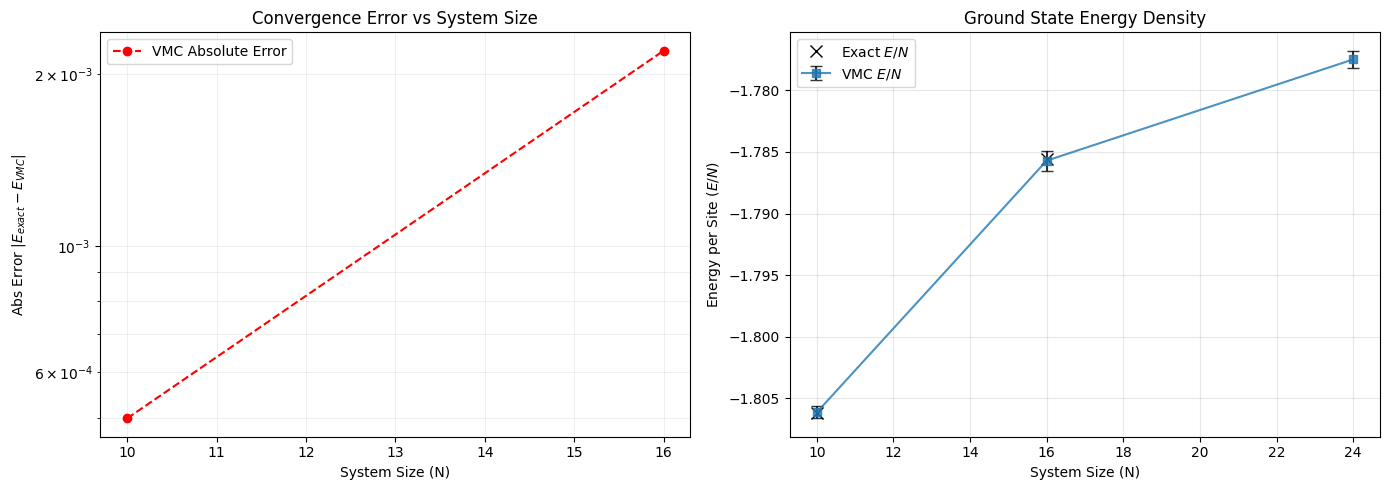

In [ ]:
import matplotlib.pyplot as plt

# 1. Extract data for plotting
# Absolute error plot (only where Exact exists)
n_vals_error = [d['N'] for d in data if d['Error'] is not None]
error_vals = [d['Error'] for d in data if d['Error'] is not None]

# Data for Energy per Site (all N)
n_vals_all = [d['N'] for d in data]
vmc_en_per_site = [d['VMC'] / d['N'] for d in data]
vmc_err_per_site = [d['VMC_err'] / d['N'] for d in data] # Error normalized by N

# Exact values for comparison (only where they exist)
n_vals_exact = [d['N'] for d in data if d['Exact'] is not None]
exact_en_per_site = [d['Exact'] / d['N'] for d in data if d['Exact'] is not None]

# 2. Create the Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Absolute Error (Log Scale) ---
if error_vals:
    ax1.plot(n_vals_error, error_vals, 'o--', color='red', label='VMC Absolute Error')
    ax1.set_yscale('log')
    ax1.set_xlabel('System Size (N)')
    ax1.set_ylabel(r'Abs Error $|E_{exact} - E_{VMC}|$')
    ax1.set_title('Convergence Error vs System Size')
    ax1.grid(True, which="both", ls="-", alpha=0.2)
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'No Exact Data available for Error Plot',
             ha='center', va='center', transform=ax1.transAxes)

# --- Plot 2: Energy per Site with Statistical Error Bars ---
# We use errorbar() to show the Monte Carlo uncertainty
ax2.errorbar(n_vals_all, vmc_en_per_site, yerr=vmc_err_per_site,
             fmt='s-', color='tab:blue', ecolor='black', capsize=4,
             label='VMC $E/N$', alpha=0.8)

# Overlay Exact values if they exist
if exact_en_per_site:
    ax2.plot(n_vals_exact, exact_en_per_site, 'x',
             color='black', markersize=8, label='Exact $E/N$')

ax2.set_xlabel('System Size (N)')
ax2.set_ylabel('Energy per Site ($E/N$)')
ax2.set_title('Ground State Energy Density')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("heisenberg_benchmark_with_errors.png")
plt.show()

In [ ]:
import netket as nk
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def get_comparison_data(n_sites_list):
    results = []

    for n in n_sites_list:
        print(f"--- Analyzing N = {n} ---")

        # Lattice and Hamiltonian
        #graph = nk.graph.Hypercube(length=n, n_dim=1, pbc=True)
        graph=nk.graph.Chain(n)
        hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=graph.n_nodes)
        hamiltonian = nk.operator.Heisenberg(hilbert=hi, graph=graph)



        # 3. Neural Network (RBM)
        model = nk.models.RBM(alpha=1, param_dtype=float)
        sampler = nk.sampler.MetropolisExchange(hi, graph=graph)

        vstate = nk.vqs.MCState(sampler, model, n_samples=1008)

# Neel state

        n_chains = vstate.sampler.n_chains
        neel = np.ones(n)
        neel[1::2] = -1

        neel_samples = np.tile(neel, (n_chains, 1)).astype(np.int8)


        vstate.sampler_state = vstate.sampler_state.replace(σ=jnp.array(neel_samples))

        # Optimizer: Stochastic Reconfiguration (SR)
        optimizer = nk.optimizer.Sgd(learning_rate=0.02)
        sr = nk.optimizer.SR(diag_shift=0.1)
        #vmc = nk.driver.VMC(hamiltonian, optimizer, variational_state=vstate, preconditioner=sr)
        vmc = nk.driver.VMC_SR(hamiltonian, optimizer, diag_shift=0.01, variational_state=vstate)
        # Run Optimization
        vmc.run(n_iter=200)
        e_vmc = float(vstate.expect(hamiltonian).mean.real)

        results.append({
            "N": n,
            "VMC": e_vmc,
        })

    return results


n_sizes = [144]
data = get_comparison_data(n_sizes)

# 4. Print

for d in data:
    #status = f"Diff: {d['Error']:.6f}" if d['Error'] is not None else "Exact not computed"
    print(f"N={d['N']} | VMC: {d['VMC']:.5f} ")

--- Analyzing N = 144 ---
Automatic SR implementation choice:  NTK


  0%|          | 0/200 [00:00<?, ?it/s]

N=144 | VMC: -207.29339 
